In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Dataset input file path
import os
file_path = "../data/university_student_retention_dataset_2134.csv"


In [3]:
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Dataset file not found at: {file_path}")

df = pd.read_csv(file_path)
print("Dataset loaded successfully from:", file_path)


Dataset loaded successfully from: ../data/university_student_retention_dataset_2134.csv


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()
df.tail()
df.sample(10, random_state=42)
df.info()
print(df.columns.tolist())
rows, columns = df.shape

print(f"Rows    : {rows}")
print(f"Columns : {columns}")
df.dtypes

Number of rows: 2134
Number of columns: 22
<class 'pandas.DataFrame'>
RangeIndex: 2134 entries, 0 to 2133
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              2134 non-null   str    
 1   age                     2134 non-null   int64  
 2   gender                  2134 non-null   str    
 3   ethnicity               2134 non-null   str    
 4   major                   2134 non-null   str    
 5   gpa_current             2134 non-null   float64
 6   gpa_history             2134 non-null   float64
 7   attendance_rate         2134 non-null   float64
 8   enrollment_gap_months   2134 non-null   int64  
 9   credits_completed       2134 non-null   int64  
 10  financial_aid_status    2134 non-null   bool   
 11  academic_warning_count  2134 non-null   int64  
 12  advisor_meeting_count   2134 non-null   int64  
 13  advising_notes          2134 non-null   str    
 14  counseli

student_id                    str
age                         int64
gender                        str
ethnicity                     str
major                         str
gpa_current               float64
gpa_history               float64
attendance_rate           float64
enrollment_gap_months       int64
credits_completed           int64
financial_aid_status         bool
academic_warning_count      int64
advisor_meeting_count       int64
advising_notes                str
counseling_notes              str
gpa_by_semester               str
attendance_by_semester        str
dropout_risk                 bool
next_semester_dropout        bool
dropout_type                  str
dropout_duration            int64
dropout_cause                 str
dtype: object

In [5]:
#Separate Numerical and Categorical Columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(include='object').columns.tolist()

boolean_columns = df.select_dtypes(include='bool').columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

print("\nBoolean columns:")
print(boolean_columns)

Numerical columns:
['age', 'gpa_current', 'gpa_history', 'attendance_rate', 'enrollment_gap_months', 'credits_completed', 'academic_warning_count', 'advisor_meeting_count', 'dropout_duration']

Categorical columns:
['student_id', 'gender', 'ethnicity', 'major', 'advising_notes', 'counseling_notes', 'gpa_by_semester', 'attendance_by_semester', 'dropout_type', 'dropout_cause']

Boolean columns:
['financial_aid_status', 'dropout_risk', 'next_semester_dropout']


In [6]:
#Basic Statistical Summary
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,2134.0,23.398782,3.446030,18.00,20.00,23.00,26.00,29.00
gpa_current,2134.0,2.757057,0.719904,1.50,2.14,2.77,3.37,4.00
gpa_history,2134.0,2.503261,0.738289,1.05,1.89,2.49,3.12,3.99
attendance_rate,2134.0,0.752760,0.143636,0.50,0.64,0.75,0.87,1.00
enrollment_gap_months,2134.0,0.992971,1.140996,0.00,0.00,1.00,2.00,3.00
credits_completed,2134.0,69.870665,29.008691,20.00,44.00,71.00,95.00,119.00
academic_warning_count,2134.0,1.538894,1.122642,0.00,1.00,2.00,3.00,3.00
advisor_meeting_count,2134.0,2.475164,1.701353,0.00,1.00,2.00,4.00,5.00
dropout_duration,2134.0,0.357076,0.839683,0.00,0.00,0.00,0.00,3.00


In [7]:
#Categorical Summary
df[categorical_columns].describe().T

,count,unique,top,freq
student_id,2134,2134,S1000,1
gender,2134,3,Female,731
ethnicity,2134,5,Asian,440
major,2134,5,Business,456
advising_notes,2134,1,Student discussed academic goals and current c...,2134
counseling_notes,653,1,Reported stress and difficulty with time manag...,653
gpa_by_semester,2134,2134,"[2.44, 2.24, 3.12, 2.32]",1
attendance_by_semester,2134,2134,"[0.82, 0.8, 0.78, 0.69]",1
dropout_type,598,3,Permanent,221
dropout_cause,598,4,Academic,156


In [8]:
#Very important because sometimes a column looks categorical but actually contains only one value.
for column in df.columns:
    print(f"\n{column}")
    print("Unique values:", df[column].nunique())


student_id
Unique values: 2134

age
Unique values: 12

gender
Unique values: 3

ethnicity
Unique values: 5

major
Unique values: 5

gpa_current
Unique values: 251

gpa_history
Unique values: 288

attendance_rate
Unique values: 51

enrollment_gap_months
Unique values: 4

credits_completed
Unique values: 100

financial_aid_status
Unique values: 2

academic_warning_count
Unique values: 4

advisor_meeting_count
Unique values: 6

advising_notes
Unique values: 1

counseling_notes
Unique values: 1

gpa_by_semester
Unique values: 2134

attendance_by_semester
Unique values: 2134

dropout_risk
Unique values: 2

next_semester_dropout
Unique values: 2

dropout_type
Unique values: 3

dropout_duration
Unique values: 4

dropout_cause
Unique values: 4


In [9]:
#Number of missing values
missing_values = df.isnull().sum()

print(missing_values)

student_id                   0
age                          0
gender                       0
ethnicity                    0
major                        0
gpa_current                  0
gpa_history                  0
attendance_rate              0
enrollment_gap_months        0
credits_completed            0
financial_aid_status         0
academic_warning_count       0
advisor_meeting_count        0
advising_notes               0
counseling_notes          1481
gpa_by_semester              0
attendance_by_semester       0
dropout_risk                 0
next_semester_dropout        0
dropout_type              1536
dropout_duration             0
dropout_cause             1536
dtype: int64


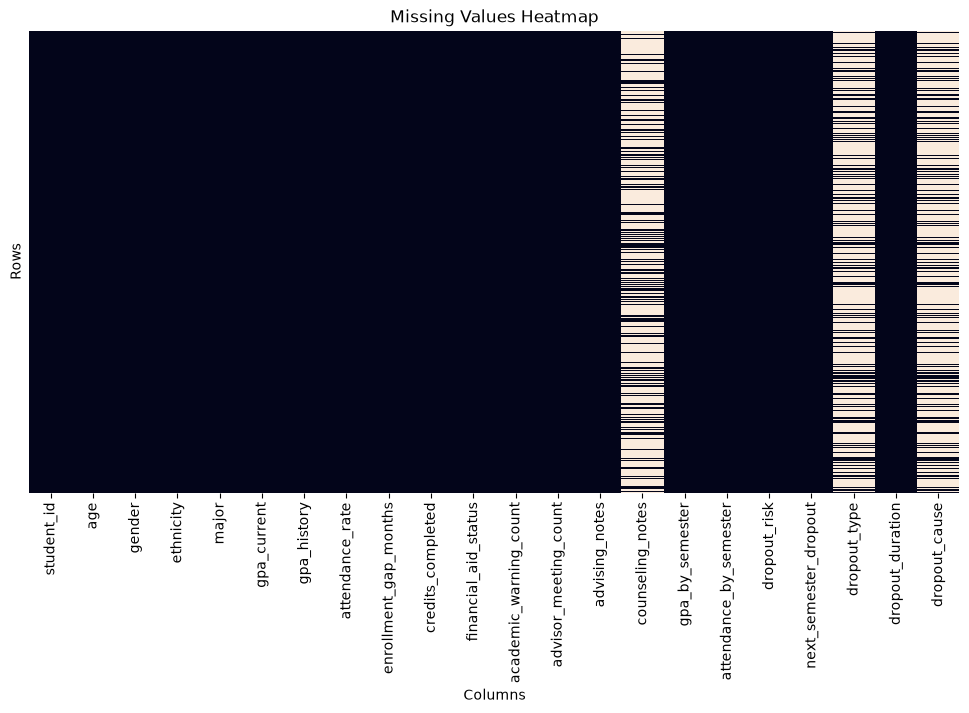

In [10]:
#Visualize Missing Values
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [11]:
#Check Duplicate Rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
#Display Duplicate Rows
duplicates = df[df.duplicated(keep=False)]

duplicates

,student_id,age,gender,ethnicity,major,gpa_current,gpa_history,attendance_rate,enrollment_gap_months,credits_completed,financial_aid_status,academic_warning_count,advisor_meeting_count,advising_notes,counseling_notes,gpa_by_semester,attendance_by_semester,dropout_risk,next_semester_dropout,dropout_type,dropout_duration,dropout_cause


In [13]:
#Check Duplicate Student IDs
#Because student_id should identify a student:

duplicate_student_ids = df['student_id'].duplicated().sum()
print("Duplicate student IDs:", duplicate_student_ids)

Duplicate student IDs: 0


In [14]:
#Check Missing Student IDs
print("Missing student IDs:", df['student_id'].isnull().sum())

Missing student IDs: 0


In [15]:
#Check Data Consistency
#Age
#Students should have a reasonable age.

print(df['age'].describe())

count    2134.000000
mean       23.398782
std         3.446030
min        18.000000
25%        20.000000
50%        23.000000
75%        26.000000
max        29.000000
Name: age, dtype: float64


In [16]:
#GPA Validation
#GPA normally has a 0–4 scale in this dataset.

print("Minimum current GPA:", df['gpa_current'].min())
print("Maximum current GPA:", df['gpa_current'].max())

Minimum current GPA: 1.5
Maximum current GPA: 4.0


In [17]:
#Attendance Validation
#Attendance should generally be between 0 and 1 in this dataset.

print(df['attendance_rate'].describe())

count    2134.000000
mean        0.752760
std         0.143636
min         0.500000
25%         0.640000
50%         0.750000
75%         0.870000
max         1.000000
Name: attendance_rate, dtype: float64


In [18]:
#Convert Attendance to Percentage for Visualization

df['attendance_percentage'] = df['attendance_rate'] * 100

#Check:

df[['attendance_rate', 'attendance_percentage']].head()

,attendance_rate,attendance_percentage
0,0.88,88.0
1,0.72,72.0
2,0.79,79.0
3,0.97,97.0
4,0.56,56.0


In [19]:
#Credits Validation
df['credits_completed'].describe()

count    2134.000000
mean       69.870665
std        29.008691
min        20.000000
25%        44.000000
50%        71.000000
75%        95.000000
max       119.000000
Name: credits_completed, dtype: float64

In [20]:
#Enrollment Gap Validation
df['enrollment_gap_months'].value_counts().sort_index()

enrollment_gap_months
0    1056
1     377
2     361
3     340
Name: count, dtype: int64

In [21]:
#Academic Warning Validation
df['academic_warning_count'].value_counts().sort_index()

academic_warning_count
0    520
1    503
2    552
3    559
Name: count, dtype: int64

In [22]:
#Advisor Meeting Validation
df['advisor_meeting_count'].value_counts().sort_index()

advisor_meeting_count
0    359
1    372
2    341
3    350
4    382
5    330
Name: count, dtype: int64

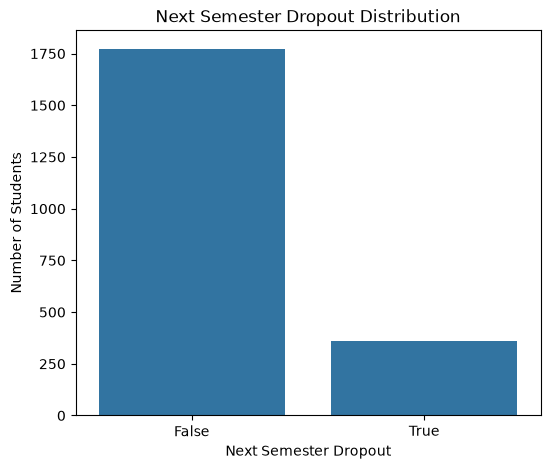

In [23]:
#Target Variable Analysis
df['next_semester_dropout'].value_counts()

plt.figure(figsize=(6, 5))

sns.countplot(data=df, x='next_semester_dropout')

plt.title("Next Semester Dropout Distribution")
plt.xlabel("Next Semester Dropout")
plt.ylabel("Number of Students")

plt.show()

In [24]:
#Check Class Imbalance

class_counts = df['next_semester_dropout'].value_counts()

print(class_counts)

print("\nClass percentages:")
print(df['next_semester_dropout'].value_counts(normalize=True) * 100)

next_semester_dropout
False    1773
True      361
Name: count, dtype: int64

Class percentages:
next_semester_dropout
False    83.083411
True     16.916589
Name: proportion, dtype: float64


In [25]:
#Dropout Risk Analysis
df['dropout_risk'].value_counts()

dropout_risk
False    1536
True      598
Name: count, dtype: int64

In [26]:
#Compare risk against actual future dropout:
pd.crosstab(
    df['dropout_risk'],
    df['next_semester_dropout'],
    margins=True
)

next_semester_dropout,False,True,All
dropout_risk,,,
False,1536,0,1536
True,237,361,598
All,1773,361,2134


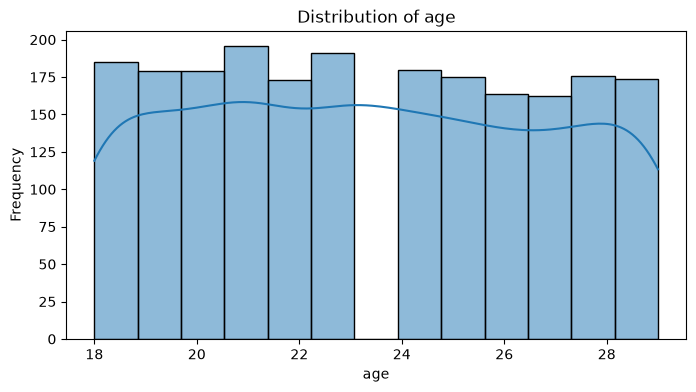

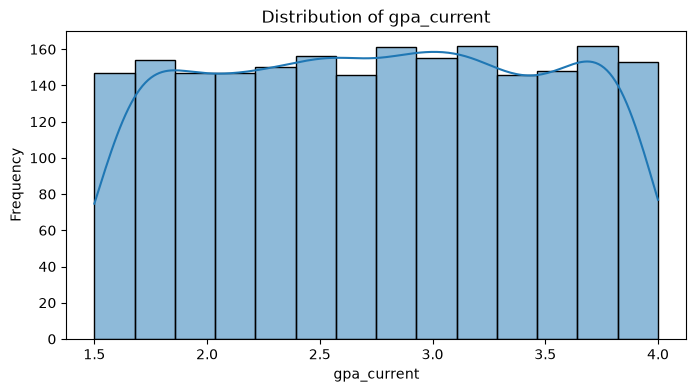

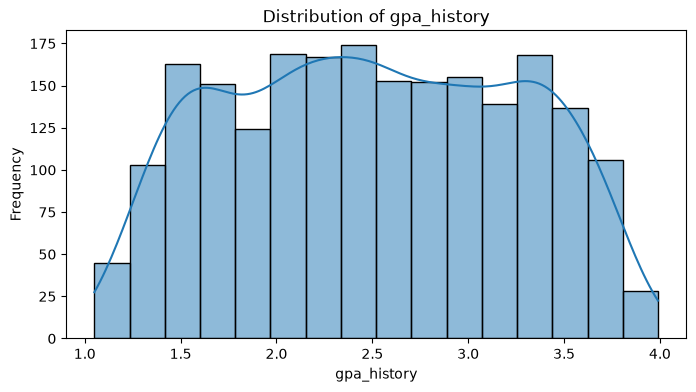

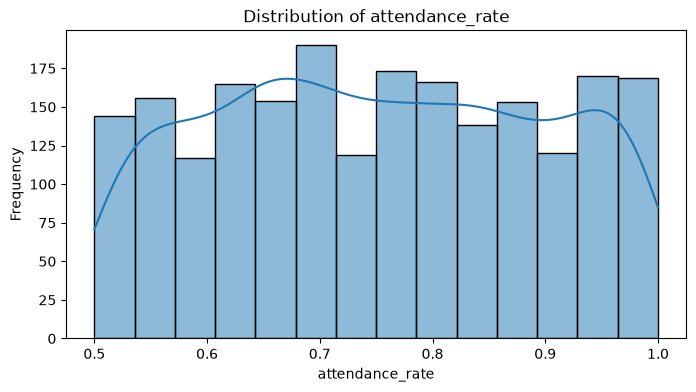

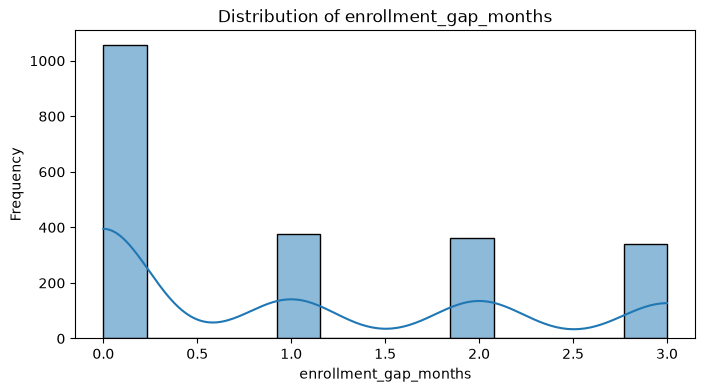

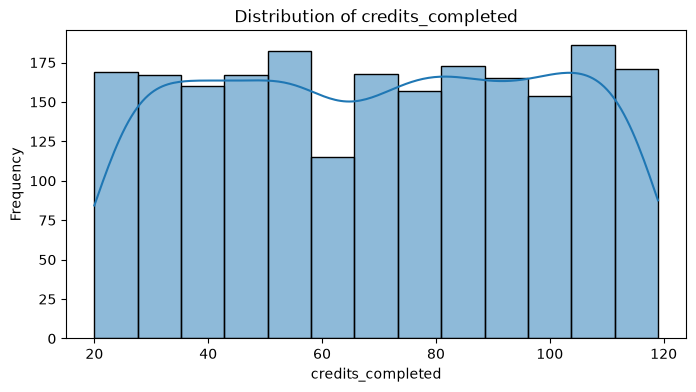

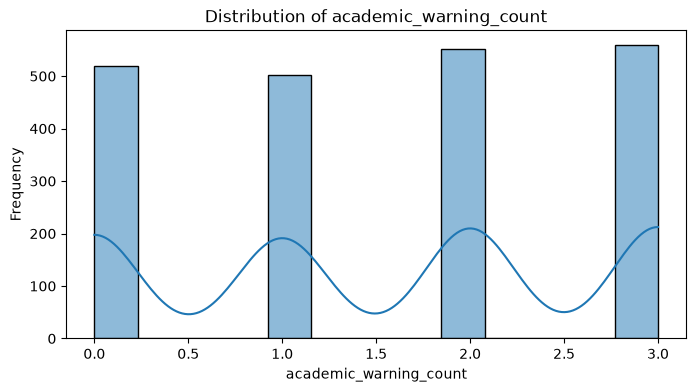

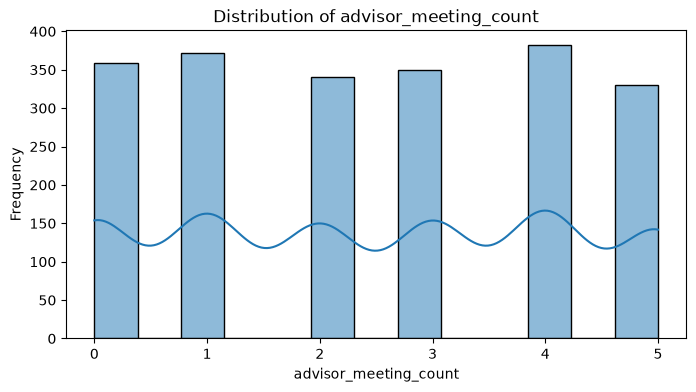

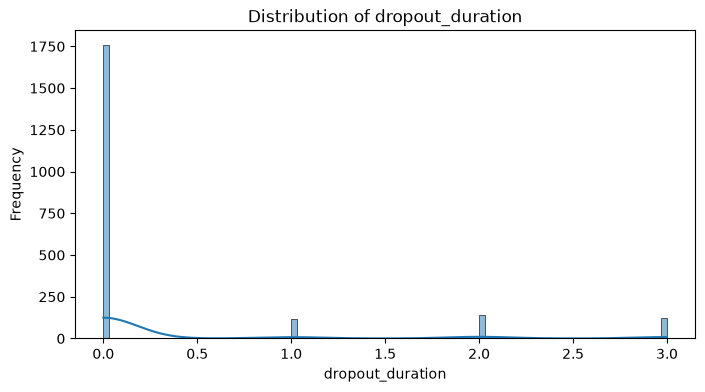

In [27]:
#Numerical Distributions
#Instead of creating separate code for every variable:

for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

In [28]:
#Skewness Table
skewness = df[numerical_columns].skew()

skewness_df = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values
})

skewness_df.sort_values(
    'Skewness',
    key=abs,
    ascending=False
)

,Feature,Skewness
8,dropout_duration,2.241411
4,enrollment_gap_months,0.658217
6,academic_warning_count,-0.058388
0,age,0.050074
3,attendance_rate,0.019755
5,credits_completed,-0.017137
1,gpa_current,-0.013370
2,gpa_history,0.008441
7,advisor_meeting_count,0.003984


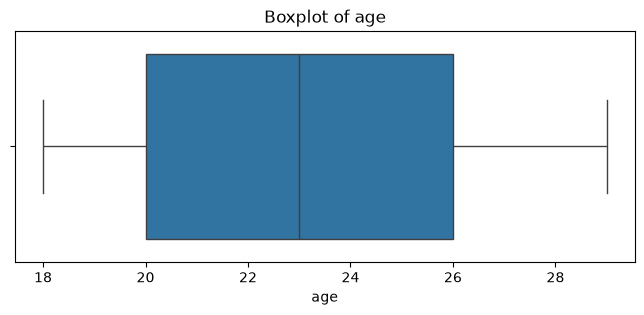

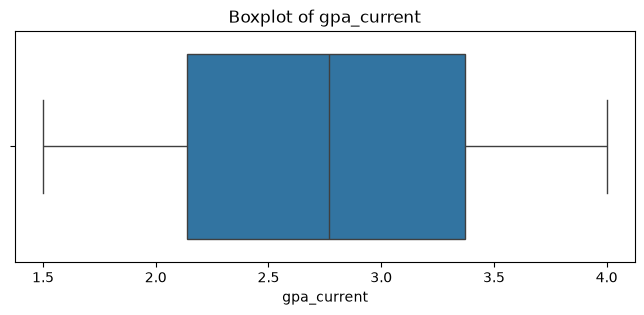

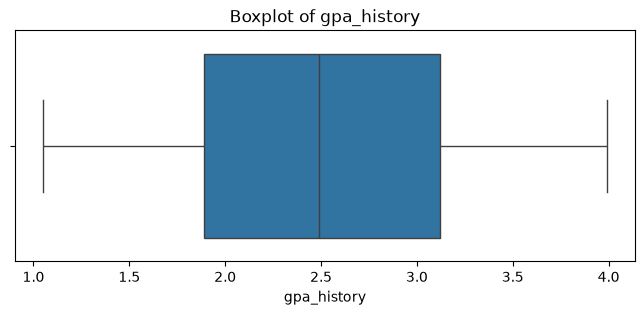

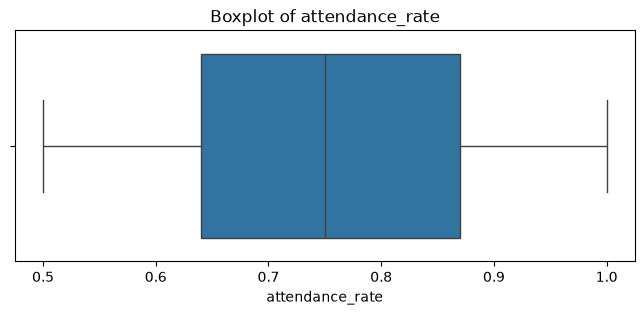

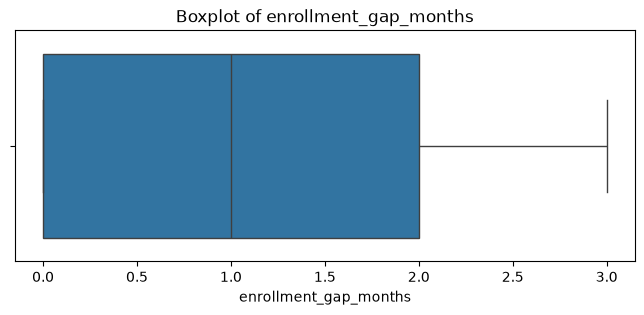

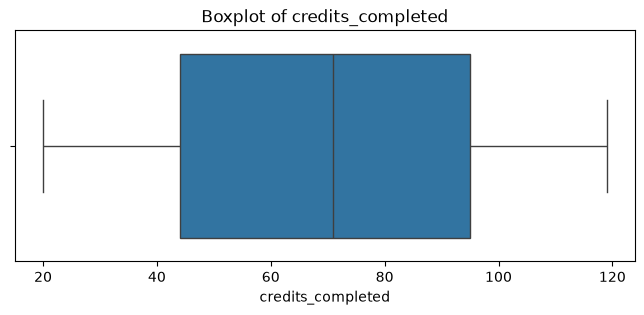

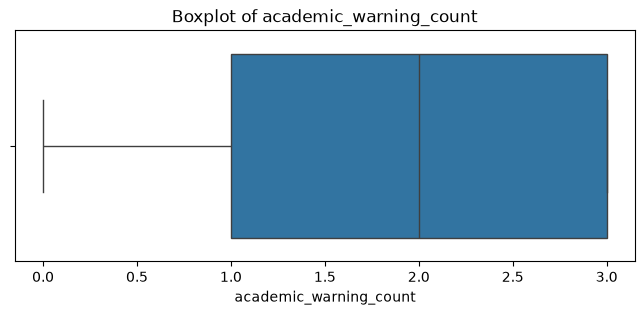

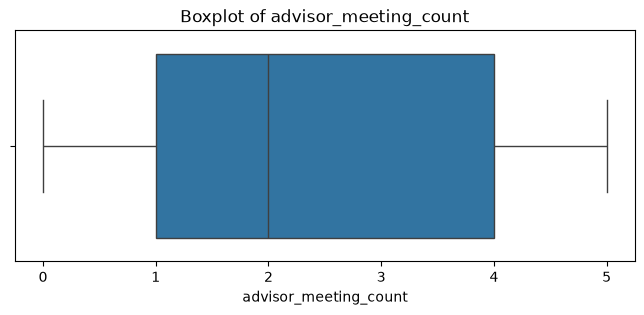

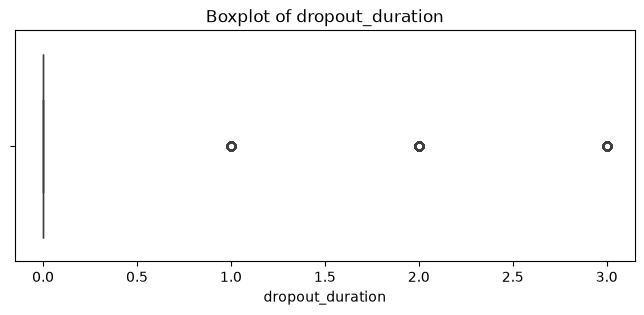

In [29]:
#Boxplots — Outlier Detection
for column in numerical_columns:

    plt.figure(figsize=(8, 3))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

In [30]:
#IQR Outlier Detection
outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        'Feature': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier %': len(outliers) / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,age,20.00,26.00,6.00,11.000,35.000,0,0.000000
1,gpa_current,2.14,3.37,1.23,0.295,5.215,0,0.000000
2,gpa_history,1.89,3.12,1.23,0.045,4.965,0,0.000000
3,attendance_rate,0.64,0.87,0.23,0.295,1.215,0,0.000000
4,enrollment_gap_months,0.00,2.00,2.00,-3.000,5.000,0,0.000000
5,credits_completed,44.00,95.00,51.00,-32.500,171.500,0,0.000000
6,academic_warning_count,1.00,3.00,2.00,-2.000,6.000,0,0.000000
7,advisor_meeting_count,1.00,4.00,3.00,-3.500,8.500,0,0.000000
8,dropout_duration,0.00,0.00,0.00,0.000,0.000,377,17.666354


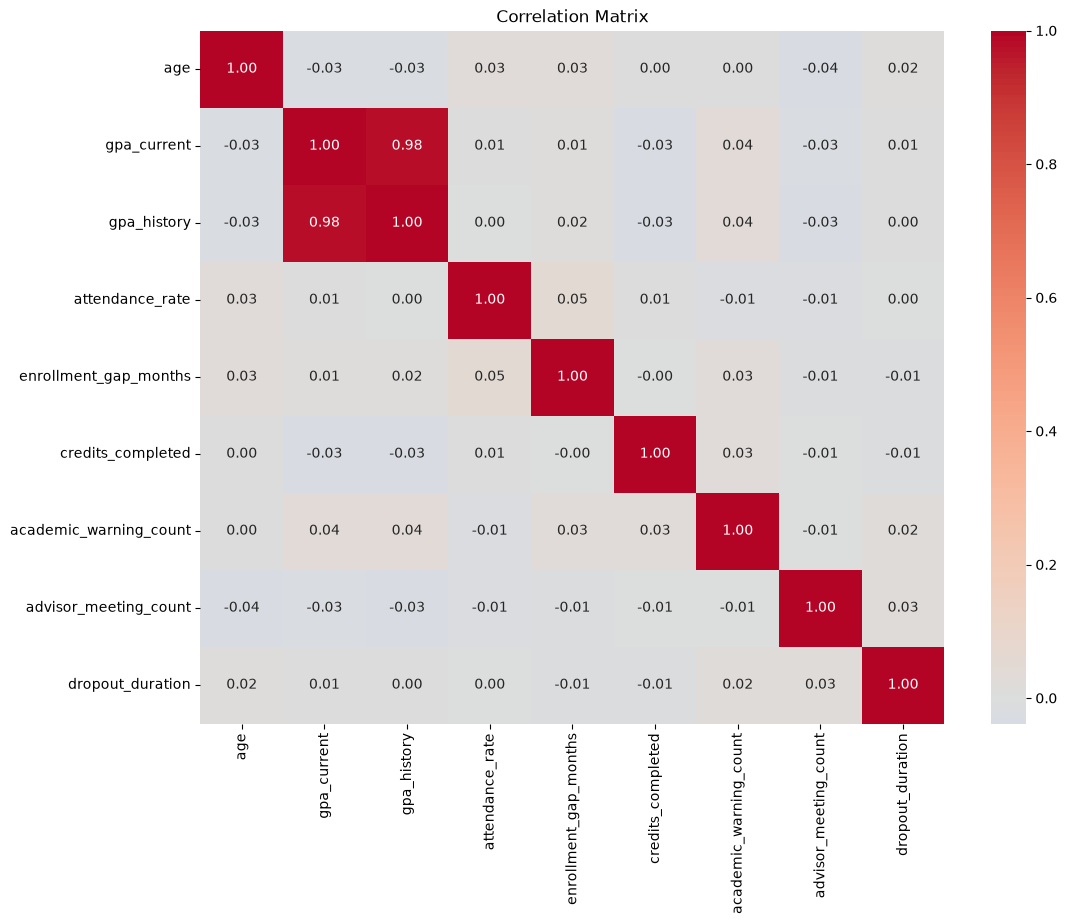

In [31]:
#Correlation Matrix For numerical variables:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix")

plt.show()

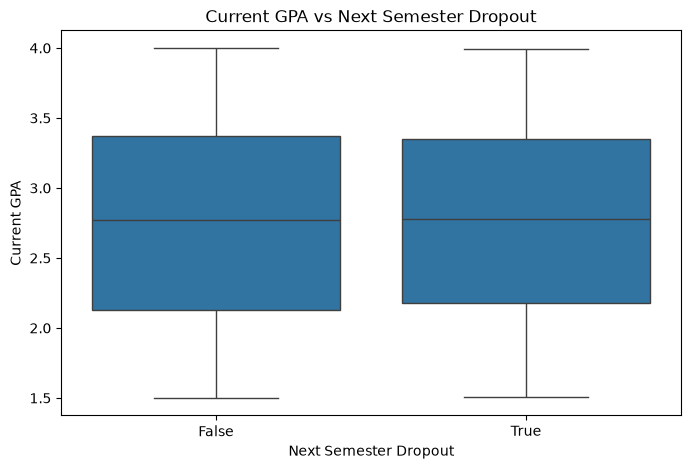

In [32]:
#GPA vs Dropout
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='next_semester_dropout',
    y='gpa_current'
)

plt.title("Current GPA vs Next Semester Dropout")
plt.xlabel("Next Semester Dropout")
plt.ylabel("Current GPA")

plt.show()

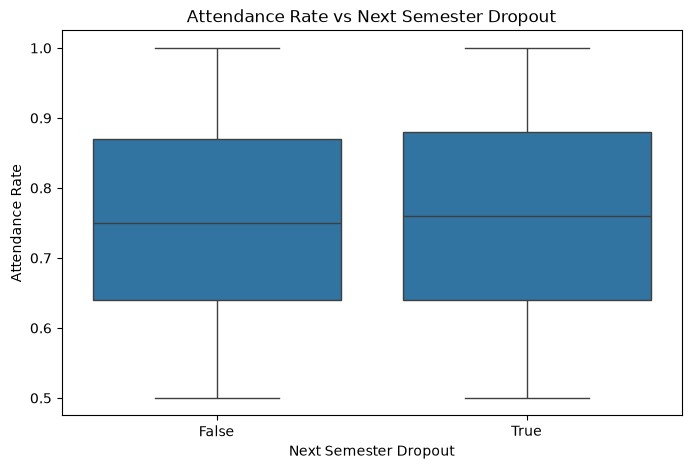

In [33]:
#Attendance vs Dropout
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='next_semester_dropout',
    y='attendance_rate'
)

plt.title("Attendance Rate vs Next Semester Dropout")
plt.xlabel("Next Semester Dropout")
plt.ylabel("Attendance Rate")

plt.show()

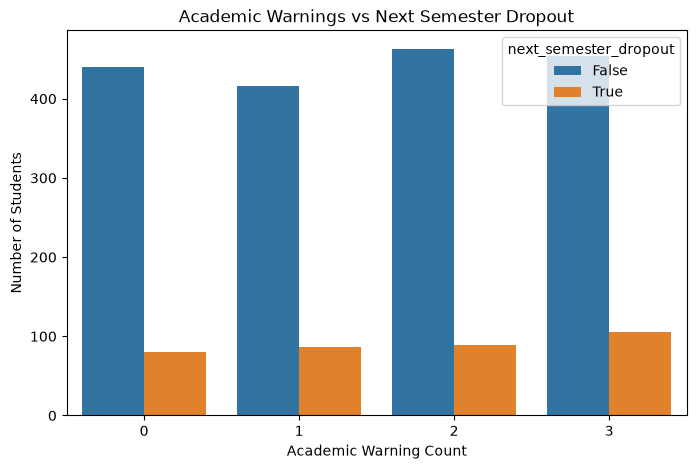

In [34]:
#Academic Warnings vs Dropout
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='academic_warning_count',
    hue='next_semester_dropout'
)

plt.title("Academic Warnings vs Next Semester Dropout")
plt.xlabel("Academic Warning Count")
plt.ylabel("Number of Students")

plt.show()

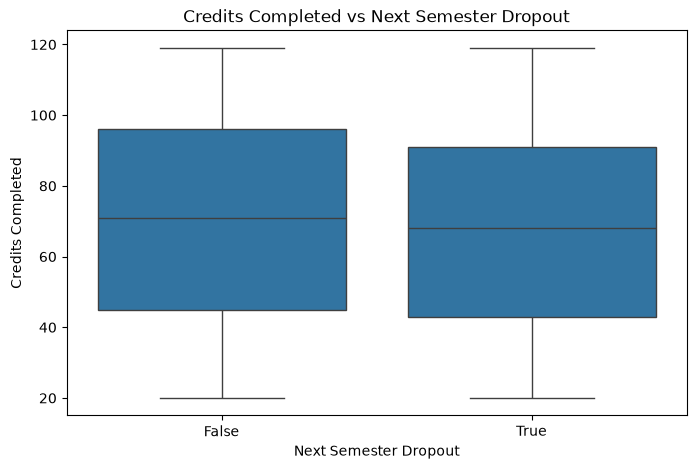

In [35]:
#Credits vs Dropout
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='next_semester_dropout',
    y='credits_completed'
)

plt.title("Credits Completed vs Next Semester Dropout")
plt.xlabel("Next Semester Dropout")
plt.ylabel("Credits Completed")

plt.show()

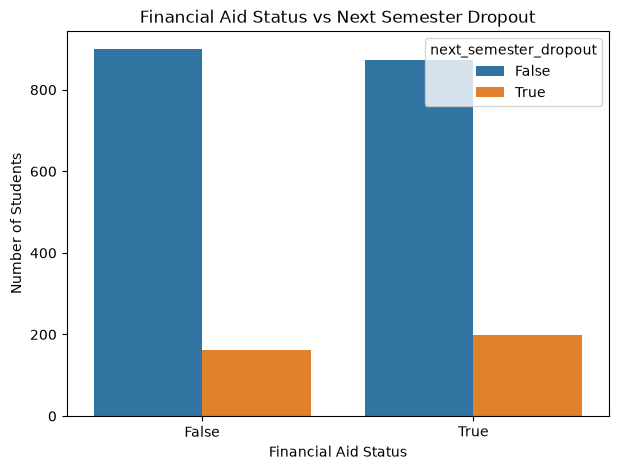

In [36]:
#Financial Aid vs Dropout
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='financial_aid_status',
    hue='next_semester_dropout'
)

plt.title("Financial Aid Status vs Next Semester Dropout")
plt.xlabel("Financial Aid Status")
plt.ylabel("Number of Students")

plt.show()

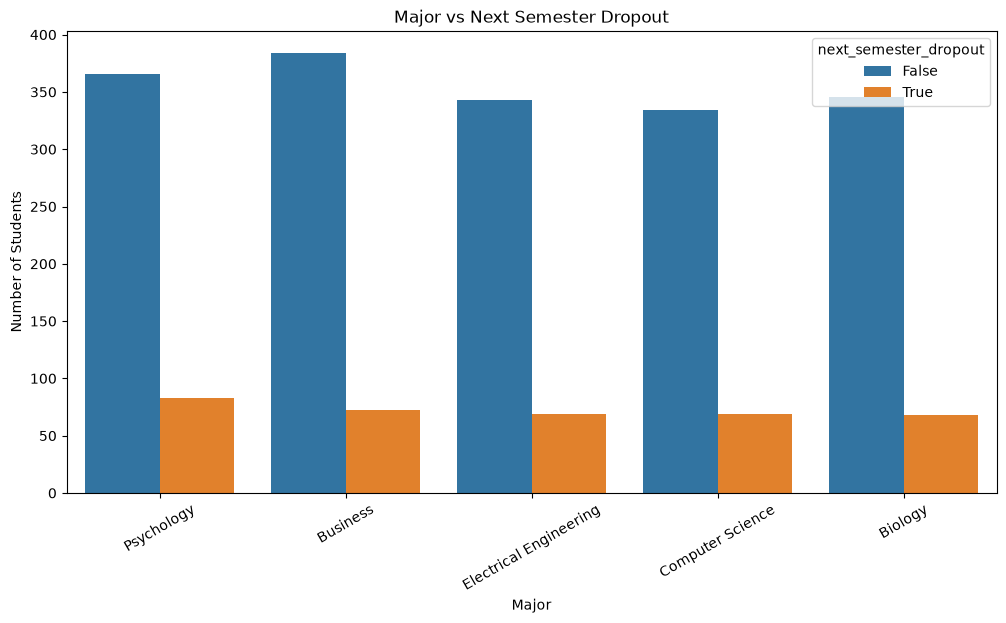

In [37]:
#Major vs Dropout
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='major',
    hue='next_semester_dropout'
)

plt.title("Major vs Next Semester Dropout")
plt.xlabel("Major")
plt.ylabel("Number of Students")

plt.xticks(rotation=30)

plt.show()

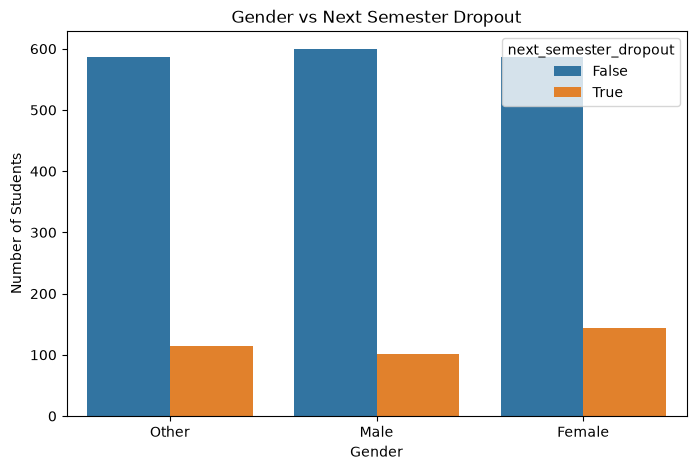

In [38]:
#Gender vs Dropout
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='gender',
    hue='next_semester_dropout'
)

plt.title("Gender vs Next Semester Dropout")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

In [39]:
#Check Relationships Using Grouped Statistics
df.groupby('next_semester_dropout')[
    numerical_columns
].mean()

#Median:

df.groupby('next_semester_dropout')[
    numerical_columns
].median()

,age,gpa_current,gpa_history,attendance_rate,enrollment_gap_months,credits_completed,academic_warning_count,advisor_meeting_count,dropout_duration
next_semester_dropout,,,,,,,,,
False,23.0,2.77,2.49,0.75,1.0,71.0,2.0,2.0,0.0
True,23.0,2.78,2.50,0.76,0.0,68.0,2.0,3.0,1.0


In [40]:
#Better Grouped Summary
group_summary = df.groupby(
    'next_semester_dropout'
)[
    [
        'age',
        'gpa_current',
        'gpa_history',
        'attendance_rate',
        'enrollment_gap_months',
        'credits_completed',
        'academic_warning_count',
        'advisor_meeting_count'
    ]
].agg(['mean', 'median', 'std'])

group_summary

age                  gpa_current         \
                            mean median       std        mean median   
next_semester_dropout                                                  
False                  23.411168   23.0  3.440502    2.755742   2.77   
True                   23.337950   23.0  3.477216    2.763518   2.78   

                                gpa_history                  attendance_rate  \
                            std        mean median       std            mean   
next_semester_dropout                                                          
False                  0.719500    2.505025   2.49  0.738481        0.751495   
True                   0.722851    2.494598   2.50  0.738313        0.758975   

                                       enrollment_gap_months                   \
                      median       std                  mean median       std   
next_semester_dropout                                                           
False                   0.75  0.143275              1.009588    1.0  1.142459   
True                    0.76  0.145441              0.911357    0.0  1.131817   

                      credits_completed                    \
                                   mean median        std   
next_semester_dropout                                       
False                         70.288212   71.0  29.020559   
True                          67.819945   68.0  28.902869   

                      academic_warning_count                   \
                                        mean median       std   
next_semester_dropout                                           
False                               1.525099    2.0  1.121847   
True                                1.606648    2.0  1.125641   

                      advisor_meeting_count                  
                                       mean median      std  
next_semester_dropout                                        
False                              2.460801    2.0  1.69858  
True                               2.545706    3.0  1.71553

In [41]:
#Data Cleaning Decisions
df_clean = df.copy()

In [42]:
#Remove Duplicate Rows
df_clean = df_clean.drop_duplicates()

print("Shape after duplicate removal:", df_clean.shape)

Shape after duplicate removal: (2134, 23)


In [43]:
#Handle Structural Missing Values
df_clean['dropout_type'] = df_clean['dropout_type'].fillna(
    'No Dropout'
)

df_clean['dropout_cause'] = df_clean['dropout_cause'].fillna(
    'No Dropout'
)

In [44]:
#Counseling Notes
df_clean['counseling_notes'] = (
    df_clean['counseling_notes']
    .fillna('No Counseling Record')
)

In [45]:
#Remove Temporary Columns
temporary_columns = [
    'attendance_percentage',
    'dropout_target_numeric',
    'gpa_by_semester_list',
    'attendance_by_semester_list'
]

df_clean = df_clean.drop(
    columns=[c for c in temporary_columns if c in df_clean.columns]
)

In [46]:
#Check Final Clean Dataset
df_clean.info()
df_clean.shape

<class 'pandas.DataFrame'>
RangeIndex: 2134 entries, 0 to 2133
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              2134 non-null   str    
 1   age                     2134 non-null   int64  
 2   gender                  2134 non-null   str    
 3   ethnicity               2134 non-null   str    
 4   major                   2134 non-null   str    
 5   gpa_current             2134 non-null   float64
 6   gpa_history             2134 non-null   float64
 7   attendance_rate         2134 non-null   float64
 8   enrollment_gap_months   2134 non-null   int64  
 9   credits_completed       2134 non-null   int64  
 10  financial_aid_status    2134 non-null   bool   
 11  academic_warning_count  2134 non-null   int64  
 12  advisor_meeting_count   2134 non-null   int64  
 13  advising_notes          2134 non-null   str    
 14  counseling_notes        2134 non-null   str    
 15

(2134, 22)

In [47]:
#Final Missing Value Check
final_missing = pd.DataFrame({
    'Missing Count': df_clean.isnull().sum(),
    'Missing %': df_clean.isnull().mean() * 100
})

final_missing.sort_values(
    'Missing %',
    ascending=False
)

,Missing Count,Missing %
student_id,0,0.0
age,0,0.0
gender,0,0.0
ethnicity,0,0.0
major,0,0.0
gpa_current,0,0.0
gpa_history,0,0.0
attendance_rate,0,0.0
enrollment_gap_months,0,0.0
credits_completed,0,0.0


In [48]:
#Final Duplicate Check
print(
    "Duplicate rows:",
    df_clean.duplicated().sum()
)

Duplicate rows: 0


In [49]:
#Final EDA Dashboard
print("========== DATASET SUMMARY ==========")

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print(
    "Duplicate rows:",
    df_clean.duplicated().sum()
)

print(
    "Missing cells:",
    df_clean.isnull().sum().sum()
)

print(
    "Numerical features:",
    len(df_clean.select_dtypes(include=np.number).columns)
)

print(
    "Categorical features:",
    len(df_clean.select_dtypes(include='object').columns)
)

print(
    "Target distribution:"
)

print(
    df_clean['next_semester_dropout'].value_counts()
)

========== DATASET SUMMARY ==========
Rows: 2134
Columns: 22
Duplicate rows: 0
Missing cells: 0
Numerical features: 9
Categorical features: 10
Target distribution:
next_semester_dropout
False    1773
True      361
Name: count, dtype: int64


In [50]:
# Extract and save preprocessed dataset to data directory
output_path = "../data/preprocessed_university_student_retention.csv"
df_clean.to_csv(output_path, index=False)

print("========== PREPROCESSED DATASET EXPORT ==========")
print(f"Preprocessed dataset successfully extracted and saved to: {output_path}")
print(f"Shape of preprocessed dataset: {df_clean.shape}")
print("\nFirst 5 rows:")
display(df_clean.head())

========== PREPROCESSED DATASET EXPORT ==========
Preprocessed dataset successfully extracted and saved to: ../data/preprocessed_university_student_retention.csv
Shape of preprocessed dataset: (2134, 22)

First 5 rows:


,student_id,age,gender,ethnicity,major,gpa_current,gpa_history,attendance_rate,enrollment_gap_months,credits_completed,financial_aid_status,academic_warning_count,advisor_meeting_count,advising_notes,counseling_notes,gpa_by_semester,attendance_by_semester,dropout_risk,next_semester_dropout,dropout_type,dropout_duration,dropout_cause
0,S1000,21,Other,Black,Psychology,3.17,2.77,0.88,0,42,True,0,2,Student discussed academic goals and current c...,Reported stress and difficulty with time manag...,"[2.44, 2.24, 3.12, 2.32]","[0.82, 0.8, 0.78, 0.69]",False,False,No Dropout,0,No Dropout
1,S1001,26,Male,Hispanic,Business,2.99,2.72,0.72,3,109,True,2,5,Student discussed academic goals and current c...,No Counseling Record,"[3.11, 3.4, 2.75, 2.86]","[0.98, 0.92, 0.96, 0.91]",False,False,No Dropout,0,No Dropout
2,S1002,26,Other,Black,Psychology,2.45,2.25,0.79,1,119,True,2,5,Student discussed academic goals and current c...,No Counseling Record,"[3.37, 3.29, 2.8, 3.56]","[0.72, 0.95, 0.54, 0.98]",False,False,No Dropout,0,No Dropout
3,S1003,21,Other,Asian,Psychology,3.82,3.79,0.97,3,38,False,1,4,Student discussed academic goals and current c...,No Counseling Record,"[3.04, 2.81, 3.18, 3.82]","[0.77, 0.79, 0.54, 0.86]",False,False,No Dropout,0,No Dropout
4,S1004,19,Male,Hispanic,Electrical Engineering,2.18,1.97,0.56,0,26,True,3,1,Student discussed academic goals and current c...,No Counseling Record,"[3.5, 1.96, 2.24, 3.48]","[0.59, 0.96, 0.71, 0.54]",True,True,Permanent,0,Financial
